In [5]:
!pip install wfdb

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import cv2

import wfdb
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/data.zip"  # adjust path
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)  # check extracted files

['data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## kill me


In [25]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Paths
TRAIN_PATH = "data/train"
TEST_PATH = "data/test"
IMG_SIZE = (512, 512)
LEADS = ['I', 'aVR','V1','V4', 'II','aVL','V2','V5','III','aVF','V3','V6']
FS = 500  # Hz

In [4]:
def preprocess_image(img, visualize=True):
    """Step 1: HSV color filtering + morphology to isolate ECG signal"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 0, 0])
    upper = np.array([150, 255, 100])
    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((2,2), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.dilate(mask, kernel, iterations=1)

    if visualize:
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original ECG Image")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='gray')
        plt.title("Processed Mask")
        plt.axis("off")
        plt.show()

    return mask


In [5]:
def remove_border_components(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    h, w = mask.shape
    clean = np.zeros_like(mask)

    for i in range(1, num_labels):
        x, y, width, height, area = stats[i]

        # check if component touches image border
        touches_border = (
            x == 0 or y == 0 or
            x + width >= w-1 or
            y + height >= h-1
        )

        if not touches_border:
            clean[labels == i] = 255

    return clean

In [13]:
def morphological_reconstruction(marker, mask):
    kernel = np.ones((3,3), np.uint8)

    prev = np.zeros_like(marker)
    current = marker.copy()

    while True:
        prev = current.copy()

        dil = cv2.dilate(current, kernel)
        current = cv2.bitwise_and(dil, mask)

        if np.array_equal(prev, current):
            break

    return current

In [78]:
def remove_dense_components(mask, visualize=False):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    clean = np.zeros_like(mask)

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]

        density = area / (w*h)

        # ECG lines are sparse, table areas are dense
        if density < 0.7:
            clean[labels == i] = 255

    clean = morphological_reconstruction(clean, mask)

    if visualize:
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.imshow(mask, cmap='gray')
        plt.title("Original ECG Image")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(clean, cmap='gray')
        plt.title("Processed Mask")
        plt.axis("off")
        plt.show()

    return clean

In [80]:
def detect_ecg_block(mask, true_mask, margin=20, visualize=False):
    vertical_sum = mask.sum(axis=1)

    # Only consider rows with significant signal
    threshold = mask.shape[1] * 0.02  # 2% of width must be active
    rows = np.where(vertical_sum > threshold)[0]

    if len(rows) == 0:
        top, bottom = 0, mask.shape[0]
    else:
        top = max(rows[0] - margin, 0)
        bottom = min(rows[-1] + margin, mask.shape[0])

    cropped_mask = mask[top:bottom, :]
    
    if visualize:
        plt.figure(figsize=(12,3))
        plt.plot(vertical_sum, label="Vertical projection")
        plt.axvline(top, color='g', linestyle='--', label='Detected top')
        plt.axvline(bottom, color='r', linestyle='--', label='Detected bottom')
        plt.title("Vertical Projection with Cropped ECG Block")
        plt.legend()
        plt.show()

    horizontal_sum = cropped_mask.sum(axis=0)

    # Only consider rows with significant signal
    threshold = cropped_mask.shape[0] * 0.005  # 2% of width must be active
    columns = np.where(horizontal_sum > threshold)[0]
    if len(columns) == 0:
        left, right = 0, cropped_mask.shape[1]
    else:
        left = max(columns[0], 0)
        right = min(columns[-1], cropped_mask.shape[1])

    cropped_mask = cropped_mask[:, left:right]

    if visualize:
        plt.figure(figsize=(12,3))
        plt.plot(horizontal_sum, label="horizontal projection")
        plt.axvline(left, color='g', linestyle='--', label='Detected top')
        plt.axvline(right, color='r', linestyle='--', label='Detected bottom')
        plt.title("Vertical Projection with Cropped ECG Block")
        plt.legend()
        plt.show()

    true_mask_cropped = true_mask[top:bottom, left:right]
    return true_mask_cropped

In [16]:
def split_leads(mask, n_rows=4, n_cols=4):
    h, w = mask.shape
    lead_imgs = []
    row_h = h // n_rows
    col_w = w // n_cols
    for r in range(n_rows):
        for c in range(n_cols):
            lead = mask[r*row_h:(r+1)*row_h, c*col_w:(c+1)*col_w]
            lead_imgs.append(lead)
    return lead_imgs  # 12 blocks


In [17]:
def extract_wave(lead_img):
    h, w = lead_img.shape
    wave = []
    for col in range(w):
        ys = np.where(lead_img[:,col]>0)[0]
        if len(ys)>0:
            wave.append(np.median(ys))
        else:
            wave.append(h//2)  # fallback if no pixels
    return np.array(wave)


In [77]:
def estimate_px_per_mm(mask, visualize=False):
    gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY) if len(mask.shape) == 3 else mask
    proj = gray.sum(axis=1)
    
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(proj, distance=2)  # distance in pixels
    
    if len(peaks) < 2:
        return 40  # fallback: default approx 40 px/mm
    
    px_per_grid = np.median(np.diff(peaks))
    
    return px_per_grid

In [103]:
'''
def normalize_wave(wave, px_per_mm=40, gain_mV_per_10mm=1):
    wave = -wave  # invert y-axis
    wave = wave - np.mean(wave)
    scale = gain_mV_per_10mm / 10.0 * px_per_mm
    wave = wave / scale
    return wave
'''

def normalize_wave(wave, px_per_mm=20):
    wave = -wave  # invert y-axis
    # safer baseline
    #baseline = np.percentile(wave, 5)
    #wave = wave - baseline
    wave = wave - np.mean(wave)
    # convert pixels -> mV
    wave = wave / (px_per_mm * 10)  # 10 mm = 1 mV
    return wave


In [19]:
def resample_wave(wave, target_len=1250):
    x_old = np.linspace(0,1,len(wave))
    x_new = np.linspace(0,1,target_len)
    f = interp1d(x_old, wave, kind='linear')
    return f(x_new)

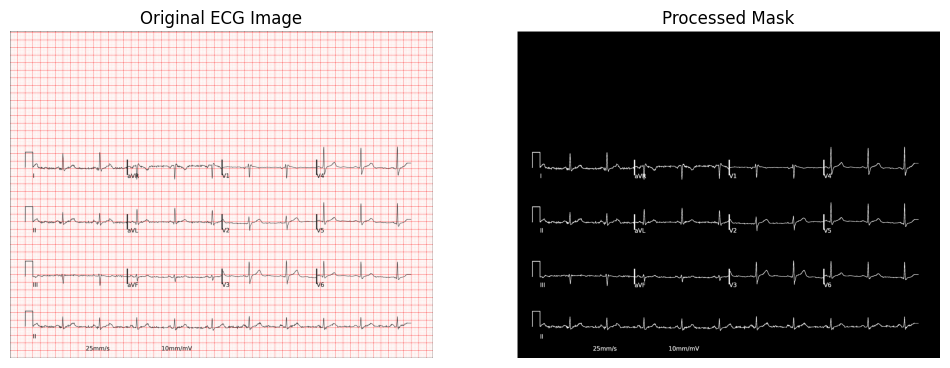

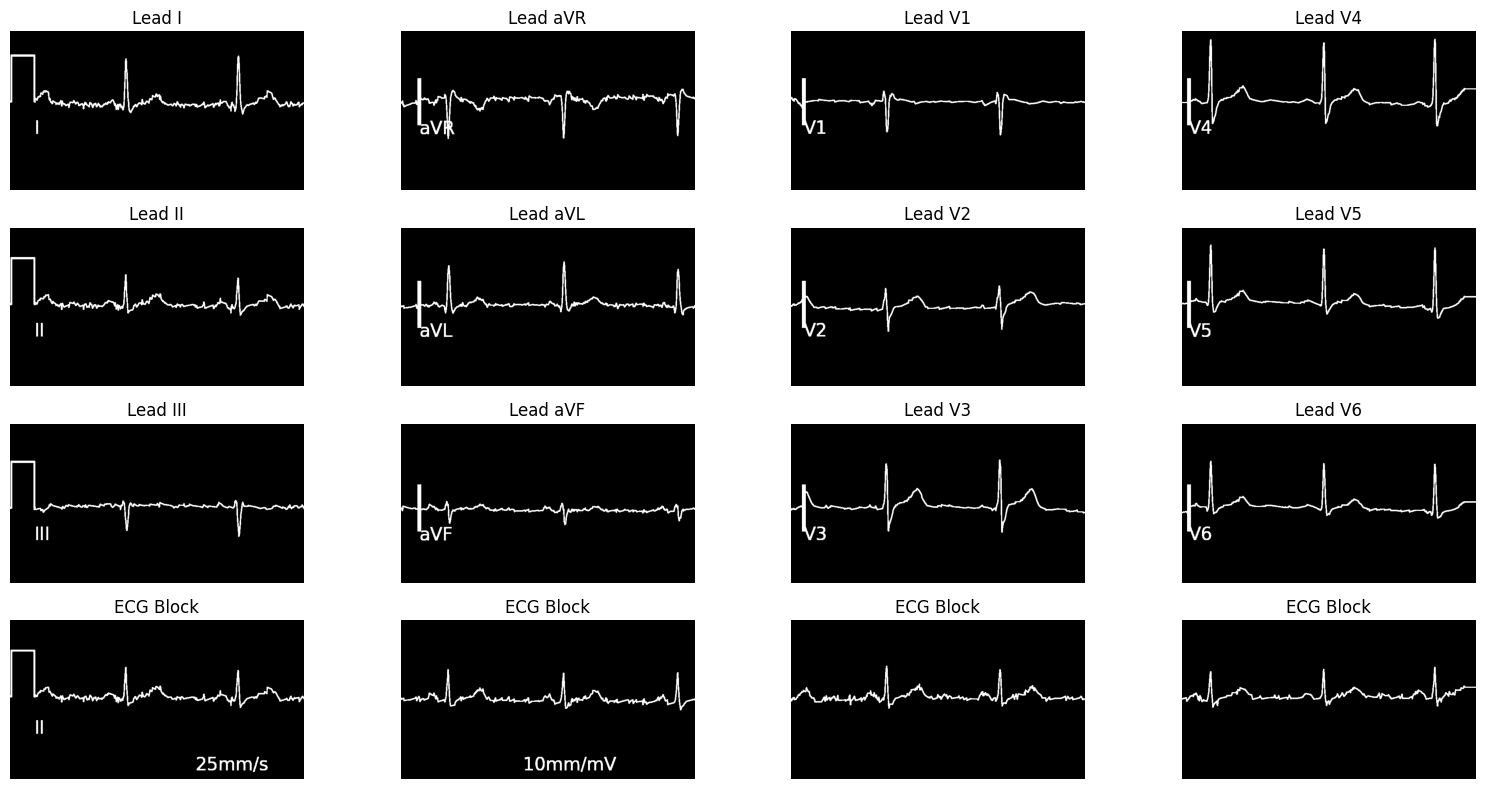

Estimated px/mm: 12.00


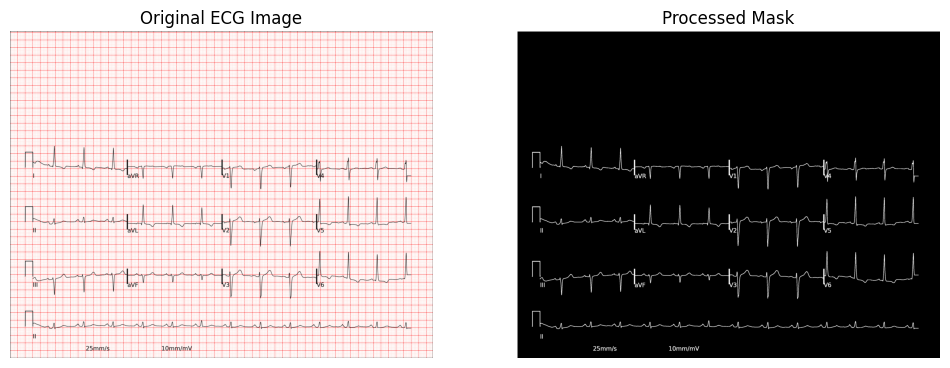

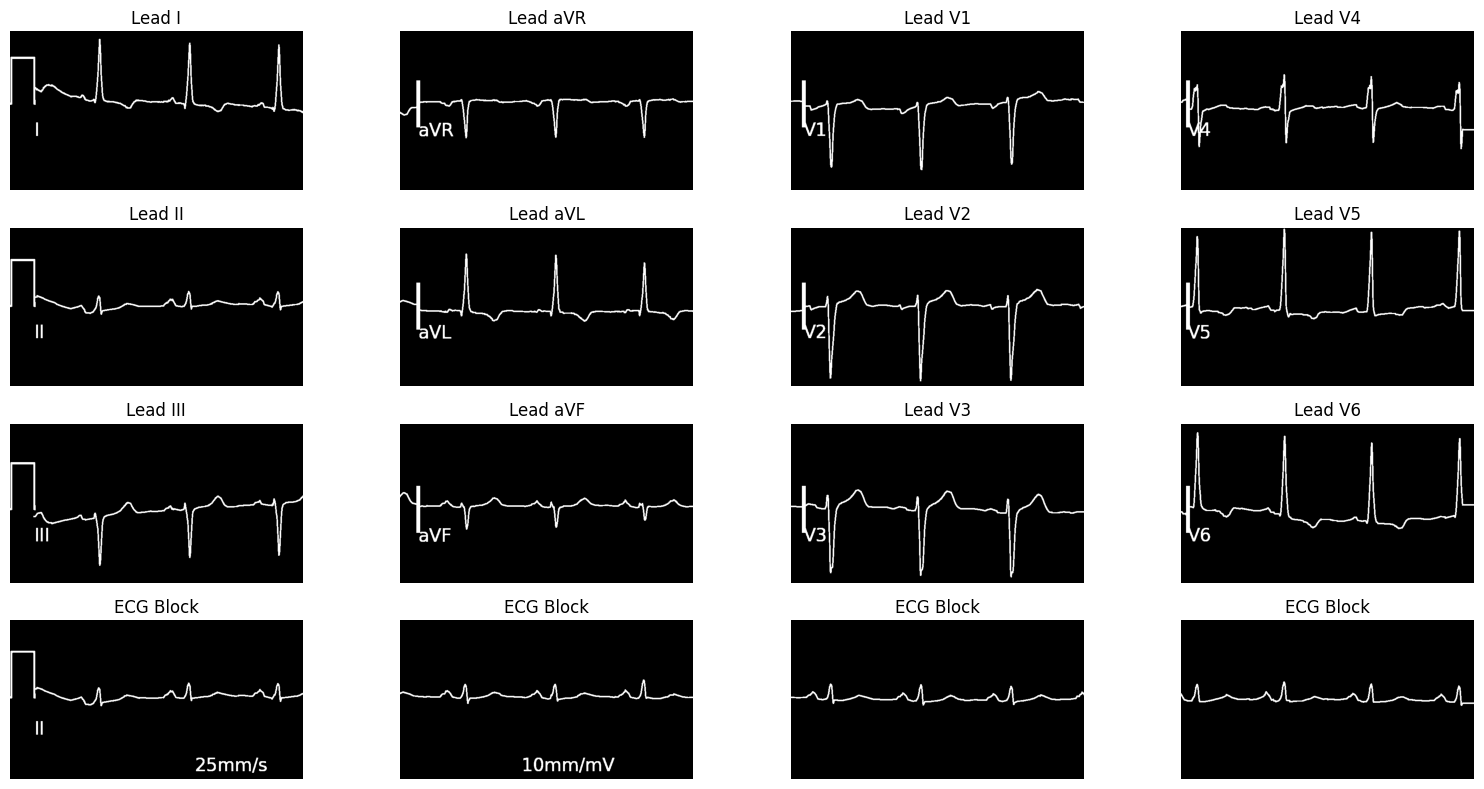

Estimated px/mm: 11.00


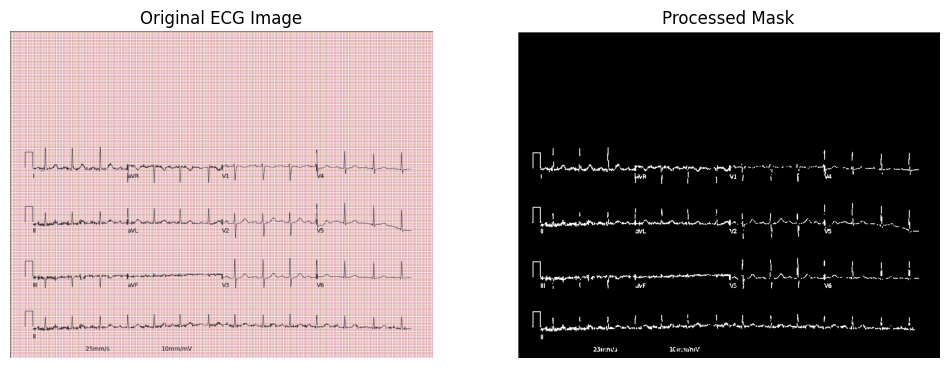

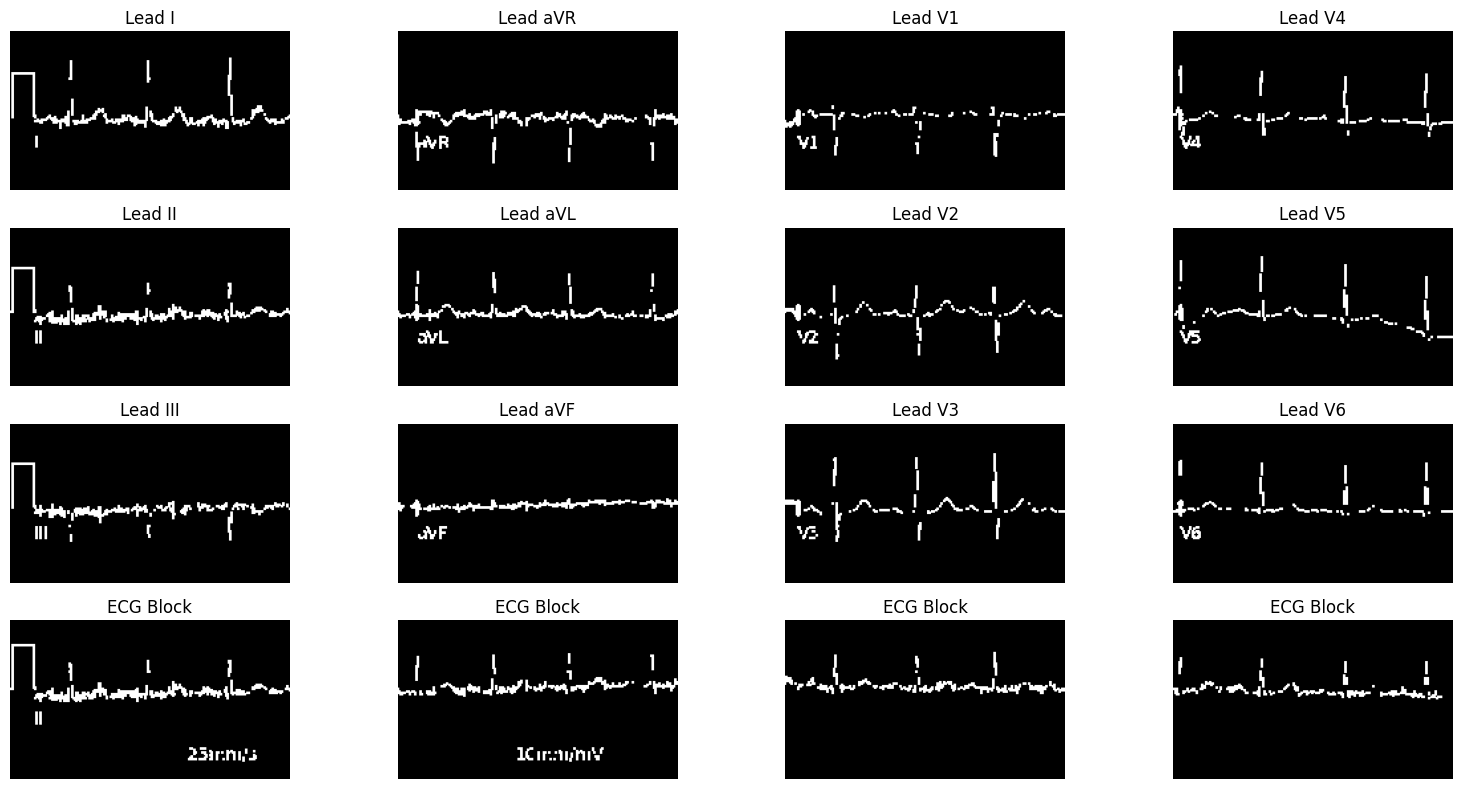

Estimated px/mm: 3.00


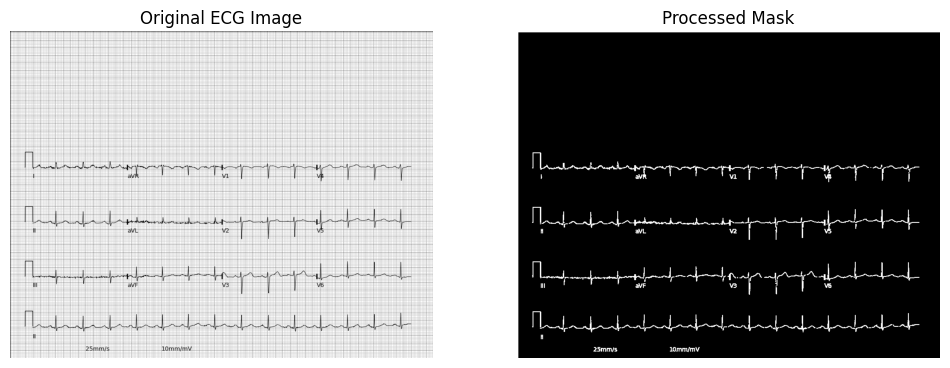

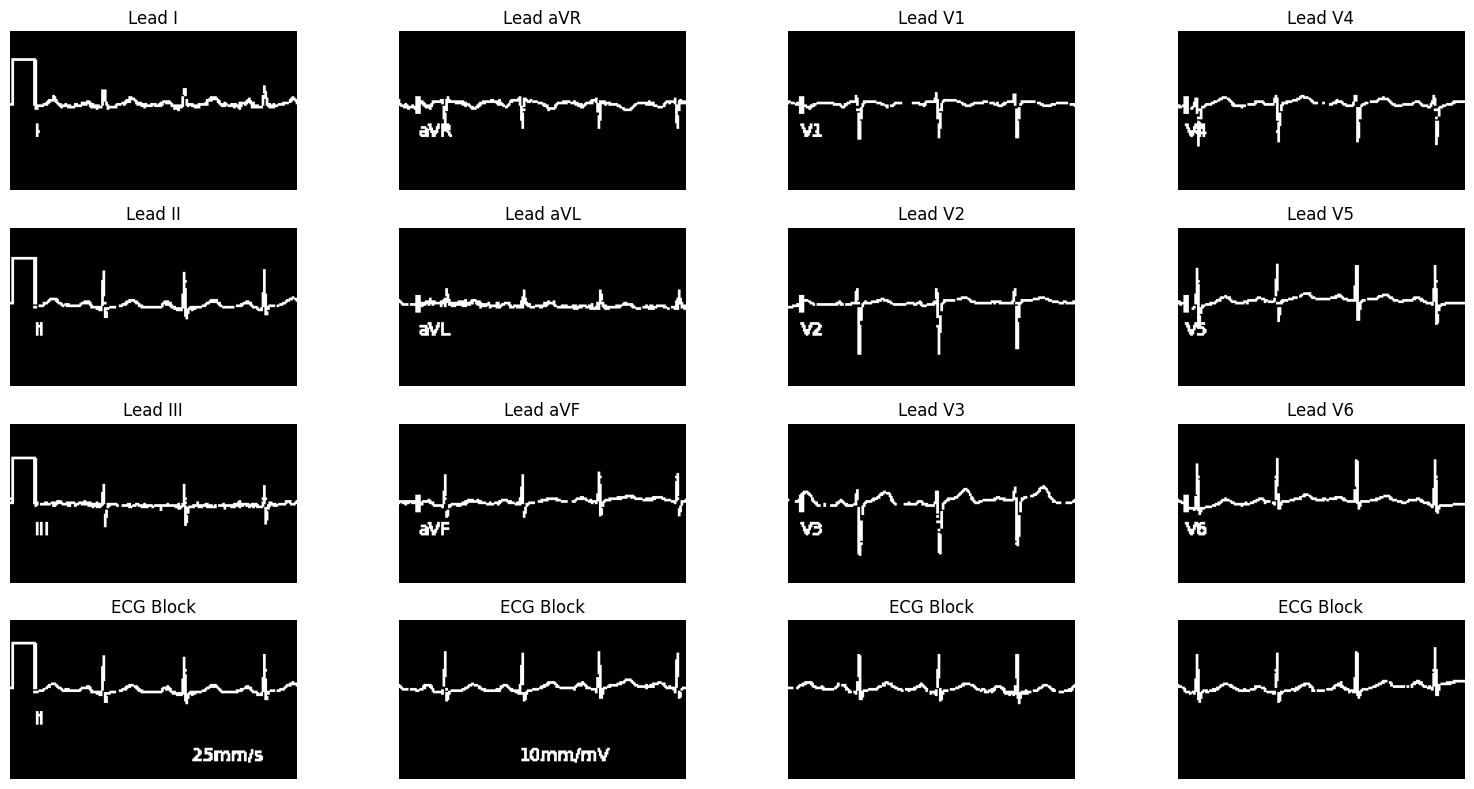

Estimated px/mm: 3.00


In [82]:
submission = {}
test_imgs = sorted(glob.glob(os.path.join(TEST_PATH,"*.png")))[0:4]
for path in test_imgs:
    name = os.path.basename(path).replace(".png","")
    img = cv2.imread(path)
    mask = preprocess_image(img)
    mask_removed = remove_border_components(mask)
    mask_removed = remove_dense_components(mask_removed)
    ecg_block = detect_ecg_block(mask_removed, true_mask=mask)
    lead_blocks = split_leads(ecg_block)
    visualize_leads(img, lead_blocks)

    px_per_mm = estimate_px_per_mm(img)
    print(f"Estimated px/mm: {px_per_mm:.2f}")
    for i, lb in enumerate(lead_blocks):
        if i > 11:
          break
        wave = extract_wave(lb)
        wave = normalize_wave(wave)
        wave = resample_wave(wave, 1250)
        submission[f"{name}_{LEADS[i]}"] = wave.astype(np.float16)
#np.savez_compressed("submission.npz", **submission)

In [21]:
def visualize_leads(original_img, lead_blocks):
    """
    original_img: full ECG image (for reference)
    lead_blocks: list of 12 numpy arrays (cropped blocks)
    """
    n_rows, n_cols = 4, 4
    plt.figure(figsize=(16,8))

    for i, lead in enumerate(lead_blocks):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(lead, cmap='gray')
        if i < 12:
            plt.title(f"Lead {LEADS[i]}")
        else:
            plt.title("ECG Block")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [55]:
def load_ground_truth(record_path):
    """
    record_path bez rozszerzenia
    np: data/train/ecg_train_0001
    """
    record = wfdb.rdrecord(record_path)

    signal = record.p_signal.T  # shape: [12, 5000]
    fs = record.fs              # powinno być 500
    print(f"Loaded {record_path} with shape {signal.shape} and fs={fs}")

    return signal, fs

In [39]:
def match_length(gt, target_len=1250):
    return gt[:, :target_len]

In [40]:
def compute_metrics(pred, gt):
    mse = np.mean((pred - gt)**2)

    corr = np.corrcoef(pred, gt)[0,1]

    return mse, corr

In [91]:
def plot_prediction_vs_gt(pred_leads, gt_leads, name):

    plt.figure(figsize=(16,10))

    for i in range(12):

        plt.subplot(6,2,i+1)

        plt.plot(gt_leads[i], label="GT", linewidth=2)
        plt.plot(pred_leads[i], label="Pred", alpha=0.7)

        plt.title(f"{name} - {LEADS[i]}")
        plt.legend()

    plt.tight_layout()
    plt.show()

In [42]:
WFDB_ORDER = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

lead_index = {l:i for i,l in enumerate(WFDB_ORDER)}

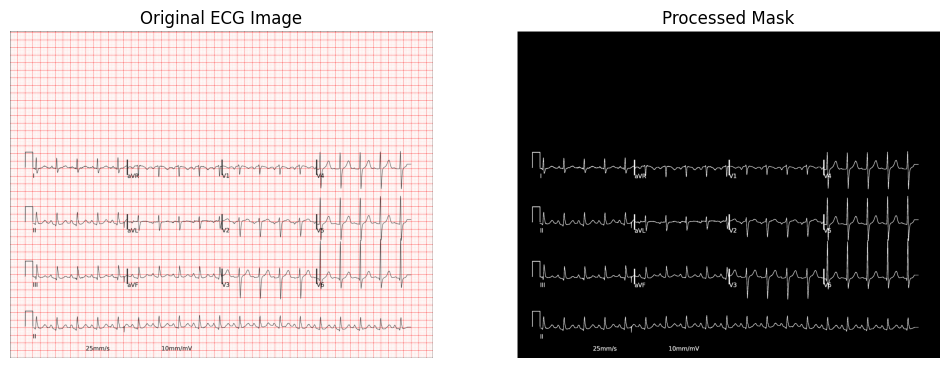

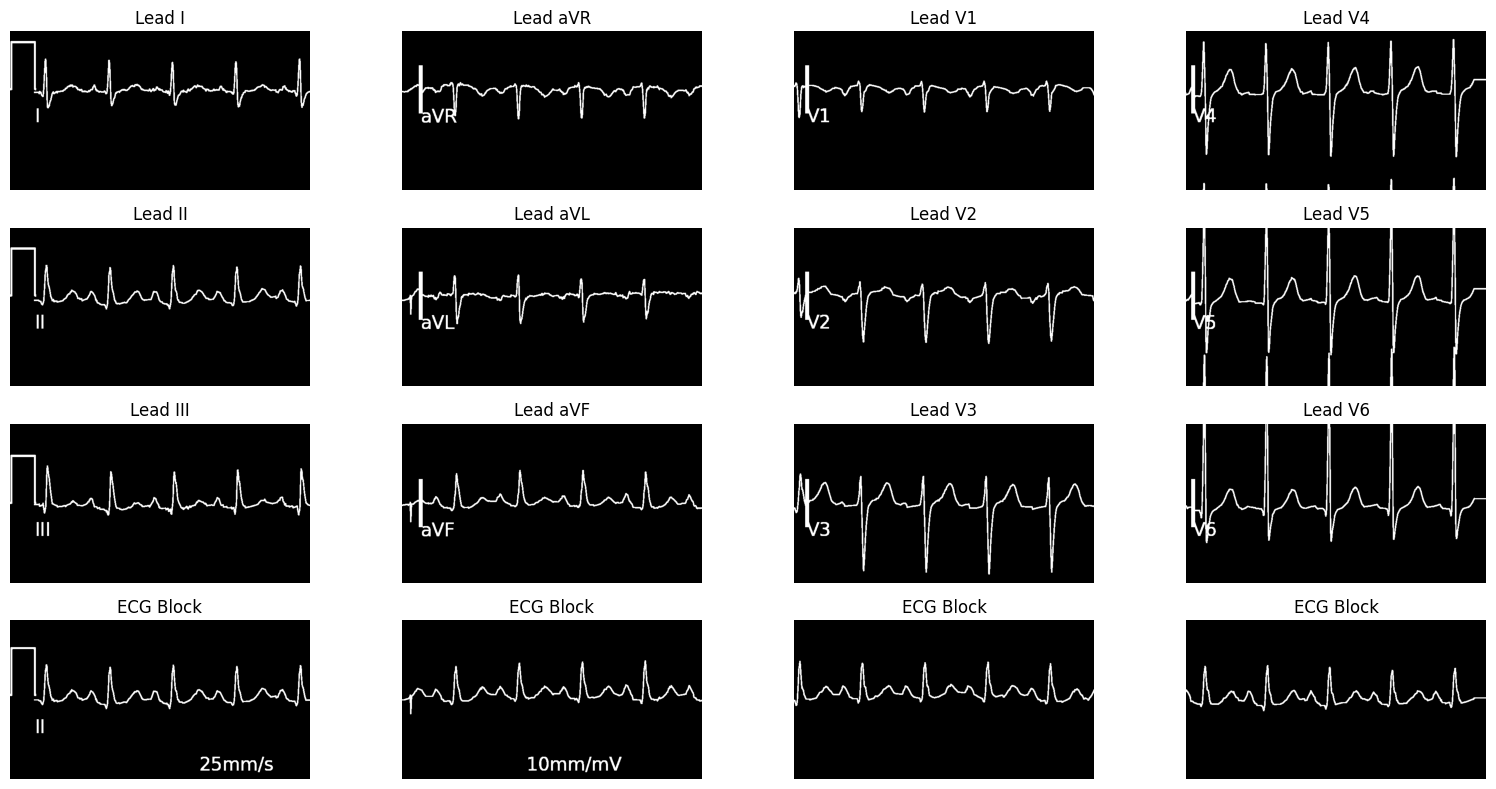

Estimated px/mm: 11.00


In [104]:
submission = {}
test_imgs = sorted(glob.glob(os.path.join(TRAIN_PATH,"*.png")))[4:5]
for path in test_imgs:
    name = os.path.basename(path).replace(".png","")
    img = cv2.imread(path)
    mask = preprocess_image(img)
    mask_removed = remove_border_components(mask)
    mask_removed = remove_dense_components(mask_removed)
    ecg_block = detect_ecg_block(mask_removed, true_mask=mask)
    lead_blocks = split_leads(ecg_block)
    visualize_leads(img, lead_blocks)

    px_per_mm = estimate_px_per_mm(img)
    print(f"Estimated px/mm: {px_per_mm:.2f}")
    for i, lb in enumerate(lead_blocks):
        if i > 11:
          break
        wave = extract_wave(lb)
        wave = normalize_wave(wave, px_per_mm=px_per_mm)
        wave = resample_wave(wave, 1250)
        submission[f"{name}_{LEADS[i]}"] = wave.astype(np.float16)
#np.savez_compressed("submission.npz", **submission)

Loaded data/train\ecg_train_0005 with shape (12, 5000) and fs=500
ecg_train_0005 I  MSE=0.1260  Corr=-0.117
ecg_train_0005 aVR  MSE=0.0487  Corr=-0.012
ecg_train_0005 V1  MSE=0.0433  Corr=-0.252
ecg_train_0005 V4  MSE=0.1458  Corr=0.382
ecg_train_0005 II  MSE=0.1191  Corr=0.158
ecg_train_0005 aVL  MSE=0.0525  Corr=-0.076
ecg_train_0005 V2  MSE=0.1231  Corr=-0.105
ecg_train_0005 V5  MSE=0.2061  Corr=0.224
ecg_train_0005 III  MSE=0.1109  Corr=0.212
ecg_train_0005 aVF  MSE=0.0603  Corr=0.082
ecg_train_0005 V3  MSE=0.2159  Corr=0.003
ecg_train_0005 V6  MSE=0.2751  Corr=0.154


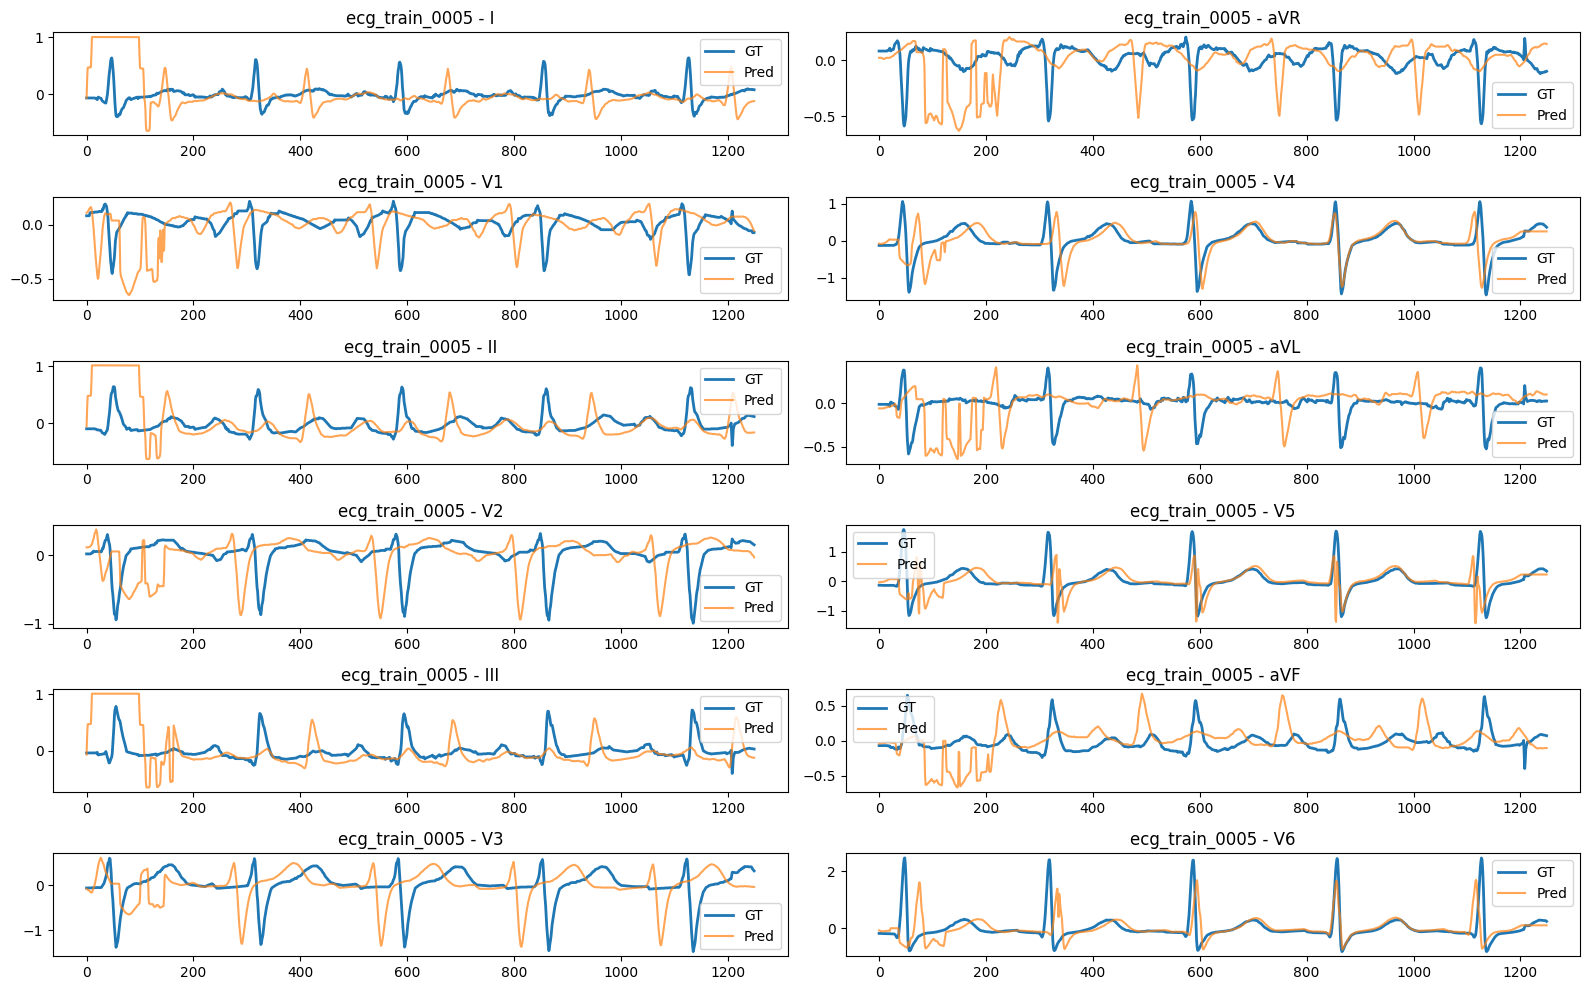

In [105]:
record_path = os.path.join(TRAIN_PATH, name)
gt_signal, fs = load_ground_truth(record_path)

gt_signal = match_length(gt_signal, 1250)

pred_leads = []
gt_leads = []

for i in range(12):
    pred = submission[f"{name}_{LEADS[i]}"]

    gt = gt_signal[lead_index[LEADS[i]]]

    pred_leads.append(pred)
    gt_leads.append(gt)

    mse, corr = compute_metrics(pred, gt)

    print(f"{name} {LEADS[i]}  MSE={mse:.4f}  Corr={corr:.3f}")

pred_leads = np.array(pred_leads)
gt_leads = np.array(gt_leads)

plot_prediction_vs_gt(pred_leads, gt_leads, name)